In [2]:
!pip install tensorflow==2.11.0

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 588.3 MB 22 kB/s 
     |████████████████████████████████| 6.0 MB 54.9 MB/s 
     |████████████████████████████████| 439 kB 78.2 MB/s 
     |████████████████████████████████| 1.7 MB 80.3 MB/s 
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.9.0
    Uninstalling tensorflow-estimator-2.9.0:
      Successfully uninstalled tensorflow-estimator-2.9.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.9.1
    Uninstalling tensorboard-2.9.1:
      Successfully uninstalled tensorboard-2.9.1
  Attempting uninstall: keras
    Found existing installation: keras 2.9.0
    Uninstalling keras-2.9.0:
      Successfully uninstalled keras-2.9.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 1.12
    Uninstalling flatbuffers-1.12:
      Successfully u

In [1]:
import tensorflow as tf
print(tf.__version__)

2.11.0


In [2]:
# fashion_mnist
import tensorflow as tf
from tensorflow import keras
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')
x_test  = x_test.astype('float32')

x_train = tf.reshape(x_train, (-1, 28*28))
x_test  = tf.reshape(x_test, (-1, 28*28))

# data normalization
x_train = x_train/255.0
x_test  = x_test/255.0

print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

4422102/4422102 [==============================] - 0s 0us/step
(60000, 784)
(10000, 784)
(60000,)
(10000,)


In [3]:
import tensorflow as tf
import tensorflow.keras as keras

# set seed
tf.random.set_seed(1234)

# create model
model = keras.Sequential()
model.add(keras.Input(shape=(784,)))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
_________________________________________________________________


In [5]:
# optimizer and loss
opt = tf.keras.optimizers.experimental.AdamW()
model.compile(optimizer=opt, 
              loss='sparse_categorical_crossentropy', 
              metrics=['sparse_categorical_accuracy'])

# training
batch_size = 256
history = model.fit(x_train, y_train, batch_size,
                    validation_data=(x_test, y_test),
                    epochs=500, verbose=2)

Epoch 1/500
235/235 - 5s - loss: 0.5995 - sparse_categorical_accuracy: 0.7981 - val_loss: 0.4462 - val_sparse_categorical_accuracy: 0.8449 - 5s/epoch - 20ms/step
Epoch 2/500
235/235 - 1s - loss: 0.4031 - sparse_categorical_accuracy: 0.8566 - val_loss: 0.4008 - val_sparse_categorical_accuracy: 0.8582 - 835ms/epoch - 4ms/step
Epoch 3/500
235/235 - 1s - loss: 0.3612 - sparse_categorical_accuracy: 0.8704 - val_loss: 0.3852 - val_sparse_categorical_accuracy: 0.8645 - 763ms/epoch - 3ms/step
Epoch 4/500
235/235 - 1s - loss: 0.3338 - sparse_categorical_accuracy: 0.8798 - val_loss: 0.3644 - val_sparse_categorical_accuracy: 0.8696 - 772ms/epoch - 3ms/step
Epoch 5/500
235/235 - 1s - loss: 0.3127 - sparse_categorical_accuracy: 0.8864 - val_loss: 0.3563 - val_sparse_categorical_accuracy: 0.8752 - 779ms/epoch - 3ms/step
Epoch 6/500
235/235 - 1s - loss: 0.2998 - sparse_categorical_accuracy: 0.8907 - val_loss: 0.3454 - val_sparse_categorical_accuracy: 0.8746 - 772ms/epoch - 3ms/step
Epoch 7/500
235/23

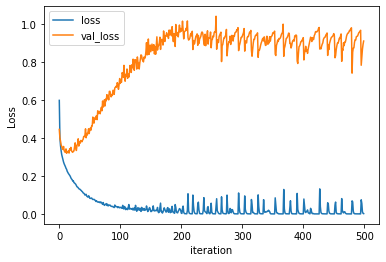

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('iteration')
plt.ylabel('Loss')
plt.legend()

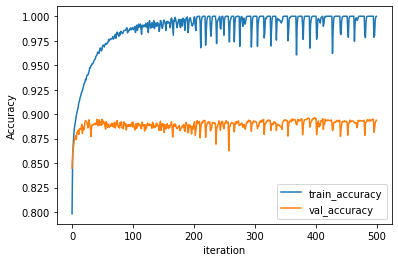

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['sparse_categorical_accuracy'], label='train_accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='val_accuracy')
plt.xlabel('iteration')
plt.ylabel('Accuracy')
plt.legend()